# LLM-as-Judge: Report Groundedness Evaluator

This notebook evaluates whether the AML investigation agent's reports are **grounded only in the provided evidence**. 

For each test case we:
1. Load the agent's artifacts (tool call results = evidence, report = output)
2. Send them to an LLM judge that scores the report on 4 dimensions
3. Aggregate results across all test cases

**Scoring rubric (0–2 each):**
| Dimension | 0 | 1 | 2 |
|---|---|---|---|
| **Attribution** | No claims cite evidence | Some claims cite evidence | All claims cite evidence |
| **Faithfulness** | Report contradicts evidence | Minor unsupported inferences | All claims faithful to evidence |
| **Coverage** | Report ignores most evidence | Partial evidence used | All key evidence reflected |
| **Hallucination** | Major fabricated claims | Minor embellishments | No hallucinated content |

In [ ]:
import json
import time
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv

# Use the existing evaluation infrastructure
from aml_agent.evaluation.graders.llm_judge import (
    LLMJudgeConfig,
    run_llm_judge_structured,
    build_judge_error_evaluation,
)
from aml_agent.evaluation.experiment import load_test_cases, load_artifacts
from aml_agent.evaluation.types import Evaluation

load_dotenv()

# Paths (matching the actual project layout)
CSV_PATH = Path("data/test_case/test_cases.csv")
ARTIFACTS_DIR = Path("output/test_cases/test_run")

print(f"CSV path:      {CSV_PATH} (exists: {CSV_PATH.exists()})")
print(f"Artifacts dir: {ARTIFACTS_DIR} (exists: {ARTIFACTS_DIR.exists()})")

# Load test cases from CSV (auto-parses JSON fields like expected_kb_watchlist_matches)
csv_rows = load_test_cases(CSV_PATH)
print(f"Loaded {len(csv_rows)} test cases from CSV")

CSV path:      data/test_case/test_cases.csv (exists: True)
Artifacts dir: output/test_cases/test_run (exists: True)
Loaded 20 test cases from CSV


## Load Artifacts & Extract Evidence

Uses `load_artifacts()` from `experiment.py` to load each test case's `Test_<TC-ID>.artifacts.json`. Then extracts **evidence** (from `tool_calls`) and **report** (from `report_markdown`) for the judge.

In [2]:
def extract_evidence(artifacts: dict) -> str:
    """Extract all retrieved evidence from tool calls into a structured text block."""
    sections = []

    for tc in artifacts.get("tool_calls", []):
        tool = tc.get("tool", "")
        response = tc.get("response", "")

        if tool == "search_knowledgebase":
            sections.append(f"### KB Watchlist Search\nQuery: {tc['args'].get('keyword', '')}\n\n{response}")
        elif tool == "web_search":
            sections.append(f"### Web Search (OpenSearch)\nQuery: {tc['args'].get('query', '')}\n\n{response}")
        elif tool == "execute":
            sections.append(f"### SQL Query Result\nQuery: {tc['args'].get('query', '')}\n\n{response}")
        elif tool == "get_schema_info":
            sections.append(f"### Database Schema\n{response}")

    # Also include structured SQL results if available
    for sr in artifacts.get("sql_results", []):
        rows_text = json.dumps(sr.get("rows", [])[:20], indent=2)
        sections.append(f"### Transaction Matches (structured)\nQuery: {sr['query']}\nColumns: {sr.get('columns')}\nRows:\n{rows_text}")

    return "\n\n---\n\n".join(sections) if sections else "(no evidence retrieved)"


# Load artifacts for each test case using experiment.load_artifacts()
test_cases = []
for row in csv_rows:
    tc_id = row["test_case_id"]
    artifacts = load_artifacts(ARTIFACTS_DIR, tc_id)
    if artifacts is None:
        print(f"  WARN: No artifacts for {tc_id}, skipping")
        continue
    test_cases.append({
        "test_case_id": tc_id,
        "subject": artifacts.get("subject", ""),
        "evidence": extract_evidence(artifacts),
        "report": artifacts.get("report_markdown", "(no report)"),
        "artifacts": artifacts,
        "csv_row": row,  # ground truth for reference
    })

print(f"Loaded {len(test_cases)} test cases with artifacts")
for tc in test_cases[:3]:
    print(f"  {tc['test_case_id']}: subject='{tc['subject'][:60]}...', "
          f"evidence_len={len(tc['evidence'])}, report_len={len(tc['report'])}")

Loaded 20 test cases with artifacts
  TC-001: subject='Run due diligence on Gpomct Grupo Empresarial....', evidence_len=14220, report_len=6720
  TC-002: subject='Conduct enhanced due diligence on Wang Mingming....', evidence_len=18857, report_len=4724
  TC-003: subject='Stakeholder flagged Jeff Young for further investigation: No...', evidence_len=22825, report_len=2474


## Explore a Single Test Case

Preview the evidence and report for one test case to sanity-check the extraction.

In [15]:
# Preview the first test case
sample = test_cases[2]
print(f"=== {sample['test_case_id']} ===")
print(f"Subject: {sample['subject']}")
print(f"\n--- EVIDENCE (first 5000 chars) ---")
print(sample["evidence"][:5000])
print(f"\n--- REPORT (first 5000 chars) ---")
print(sample["report"][:5000])

=== TC-003 ===
Subject: Stakeholder flagged Jeff Young for further investigation: No risk concerns; common name.

--- EVIDENCE (first 5000 chars) ---
### KB Watchlist Search
Query: Jeff Young

Knowledge Base Search Results for 'Jeff Young':

Result 1:
  Entity ID: NK-SfWYKfGXPqhpd34DFZ4tfH
  Name: FU YUAN YU F91
  Source: US OFAC Specially Designated Nationals (SDN)
  Score: 0.2157
  Snippet: US OFAC Specially Designated Nationals (SDN)
Name: FU YUAN YU F91
Type: Vessel
IMO Number: IMO8414295
Flag: CN
Vessel Type: Refrigerated Cargo Ship
Source URL: https://sanctionssearch.ofac.treas.gov/Details.aspx?id=33693
Program: US-GLOMAG
First seen: 2023-04-20T10:27:20
Last update: 2025-06-02T12:10:03

Result 2:
  Entity ID: NK-YkbsqiWvSaXXLDZX3rFwg7
  Name: FU YUAN YU F30
  Source: US OFAC Specially Designated Nationals (SDN)
  Score: 0.2097
  Snippet: US OFAC Specially Designated Nationals (SDN)
Name: FU YUAN YU F30
Type: Vessel
IMO Number: IMO9096507
Flag: CN
Vessel Type: Refrigerated Cargo S

## Define the LLM Judge

Uses `run_llm_judge_structured()` from `graders/llm_judge.py` which handles:
- Gemini API call with `response_mime_type="application/json"`
- OTel context detach (judge latency isn't attributed to agent traces)
- JSONL logging to `run_log/llm_as_judge/` for traceability
- Error handling via `build_judge_error_evaluation()`

The judge evaluates the report against evidence on 4 dimensions:
**Attribution**, **Faithfulness**, **Coverage**, **Hallucination** (0–2 each).

In [ ]:
METRIC_NAME = "report_groundedness"

JUDGE_SYSTEM_PROMPT = """\
You are an evaluator for an AML investigation agent.

You are given:
1. Retrieved evidence (KB watchlist, web/opensearch, transaction matches, transaction match details)
2. Generated report

Your task:
Evaluate whether the report is grounded ONLY in the provided evidence.

For each claim in the report:
- Identify supporting evidence (if any)
- Flag hallucinations (claims with no evidence support)

Then score each dimension on a 0-2 scale:

1. **Attribution** (0-2): Are claims in the report backed by cited evidence?
   - 0: No claims cite evidence
   - 1: Some claims cite evidence, others do not
   - 2: All substantive claims properly cite their evidence source

2. **Faithfulness** (0-2): Does the report accurately represent what the evidence says?
   - 0: Report contradicts or significantly misrepresents the evidence
   - 1: Mostly faithful but contains minor unsupported inferences
   - 2: All claims are faithful and accurately reflect the evidence

3. **Coverage** (0-2): Does the report reflect all key evidence found?
   - 0: Report ignores most of the retrieved evidence
   - 1: Report uses some evidence but omits significant findings
   - 2: All key evidence is reflected in the report

4. **Hallucination** (0-2): Is the report free of fabricated content?
   - 0: Contains major fabricated claims not in the evidence
   - 1: Contains minor embellishments or unverifiable details
   - 2: No hallucinated content; everything is grounded in evidence

Return ONLY valid JSON (no markdown fences, no extra text). Use this exact schema:
{
  "attribution": <0-2>,
  "faithfulness": <0-2>,
  "coverage": <0-2>,
  "hallucination": <0-2>,
  "justification": "<2-4 sentences explaining the scores, citing specific examples>"
}
"""

JUDGE_USER_PROMPT_TEMPLATE = """\
# Investigation Subject
{subject}

# Retrieved Evidence

{evidence}

# Generated Report

{report}

Evaluate whether the report is grounded in the provided evidence. Return JSON only.
"""

JUDGE_CONFIG = LLMJudgeConfig(temperature=0.0, max_output_tokens=4096)


def run_groundedness_judge(subject: str, evidence: str, report: str) -> dict:
    """Call the LLM judge via the project's existing run_llm_judge_structured().

    This uses the same Gemini client, OTel detach, and JSONL logging
    as all other LLM-as-judge graders in the project.
    """
    user_prompt = JUDGE_USER_PROMPT_TEMPLATE.format(
        subject=subject,
        evidence=evidence,
        report=report,
    )
    return run_llm_judge_structured(
        metric_name=METRIC_NAME,
        system_prompt=JUDGE_SYSTEM_PROMPT,
        user_prompt=user_prompt,
        config=JUDGE_CONFIG,
    )


print(f"Judge configured: metric_name='{METRIC_NAME}', config={JUDGE_CONFIG}")

Judge configured: metric_name='report_groundedness', config=LLMJudgeConfig(model=None, temperature=0.0, max_output_tokens=2048)


In [7]:
# Quick test on the first test case
sample = test_cases[0]

try:
    sample_result = run_groundedness_judge(
        subject=sample["subject"],
        evidence=sample["evidence"],
        report=sample["report"],
    )
except ValueError as e:
    if "invalid JSON" not in str(e):
        raise

    print("Judge response was truncated/invalid JSON. Retrying with a larger token budget...")
    JUDGE_CONFIG = LLMJudgeConfig(
        model=JUDGE_CONFIG.model,
        temperature=JUDGE_CONFIG.temperature,
        max_output_tokens=4096,
    )
    sample_result = run_groundedness_judge(
        subject=sample["subject"],
        evidence=sample["evidence"],
        report=sample["report"],
    )

print(f"Test case: {sample['test_case_id']}")
print(json.dumps(sample_result, indent=2))
print(f"\n(Judge call logged to run_log/llm_as_judge/)")

Judge response was truncated/invalid JSON. Retrying with a larger token budget...
Test case: TC-001
{
  "attribution": 1,
  "faithfulness": 2,
  "coverage": 2,
  "hallucination": 2,
  "justification": "The report accurately reflects all key evidence from the KB watchlist, transaction data, and web search. All claims are faithful to the evidence and no hallucinations were found. There is a minor attribution error where the wire transaction database [5] is incorrectly cited for information about AML failures, which is only supported by web source [1]."
}

(Judge call logged to run_log/llm_as_judge/)


## Run Judge on All Test Cases

Evaluate every test case. Results are collected into a DataFrame for analysis.

In [ ]:
SCORE_DIMS = ["attribution", "faithfulness", "coverage", "hallucination"]

results = []
evaluations_by_tc = {}  # tc_id -> list[Evaluation] for downstream compatibility

for i, tc in enumerate(test_cases):
    tc_id = tc["test_case_id"]
    print(f"[{i+1}/{len(test_cases)}] Evaluating {tc_id}...", end=" ")

    try:
        scores = run_groundedness_judge(
            subject=tc["subject"],
            evidence=tc["evidence"],
            report=tc["report"],
        )
        # Build Evaluation objects (same type used by the rest of the eval framework)
        evals = [
            Evaluation(
                name=f"{METRIC_NAME}_{dim}",
                value=scores[dim],
                comment=scores.get("justification"),
                metadata={"test_case_id": tc_id},
            )
            for dim in SCORE_DIMS
        ]
        evaluations_by_tc[tc_id] = evals

        row = {"test_case_id": tc_id, "subject": tc["subject"], "error": None,
               "justification": scores.get("justification"), **{d: scores[d] for d in SCORE_DIMS}}
        print(f"  ".join(f"{d}={scores[d]}" for d in SCORE_DIMS))

    except Exception as e:
        # Use the project's standard error Evaluation builder
        err_eval = build_judge_error_evaluation(metric_name=METRIC_NAME, error=e)
        evaluations_by_tc[tc_id] = [err_eval]

        row = {"test_case_id": tc_id, "subject": tc["subject"], "error": str(e),
               "justification": None, **{d: None for d in SCORE_DIMS}}
        print(f"ERROR: {e}")

    results.append(row)
    time.sleep(0.5)  # rate limit courtesy

df = pd.DataFrame(results)
for col in SCORE_DIMS:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(f"\nDone. {len(df)} test cases evaluated, {df['error'].notna().sum()} errors.")
df[["test_case_id"] + SCORE_DIMS + ["justification"]].head()

[1/20] Evaluating TC-001... attribution=1  faithfulness=2  coverage=2  hallucination=2
[2/20] Evaluating TC-002... attribution=2  faithfulness=2  coverage=1  hallucination=2
[3/20] Evaluating TC-003... attribution=1  faithfulness=1  coverage=2  hallucination=1
[4/20] Evaluating TC-004... attribution=2  faithfulness=2  coverage=2  hallucination=2
[5/20] Evaluating TC-005... attribution=1  faithfulness=2  coverage=2  hallucination=2
[6/20] Evaluating TC-006... attribution=2  faithfulness=2  coverage=2  hallucination=2
[7/20] Evaluating TC-007... attribution=2  faithfulness=2  coverage=2  hallucination=2
[8/20] Evaluating TC-008... attribution=0  faithfulness=0  coverage=0  hallucination=0
[9/20] Evaluating TC-009... attribution=1  faithfulness=2  coverage=2  hallucination=2
[10/20] Evaluating TC-010... attribution=2  faithfulness=2  coverage=2  hallucination=2
[11/20] Evaluating TC-011... attribution=1  faithfulness=2  coverage=2  hallucination=2
[12/20] Evaluating TC-012... attribution=

,test_case_id,attribution,faithfulness,coverage,hallucination,justification
0,TC-001,1,2,2,2,The report accurately reflects all key evidenc...
1,TC-002,2,2,1,2,"The report is well-attributed, with all substa..."
2,TC-003,1,1,2,1,"The report covers all key evidence, including ..."
3,TC-004,2,2,2,2,The report accurately attributes all substanti...
4,TC-005,1,2,2,2,The report is faithful to the evidence and cov...


In [9]:
df[["test_case_id"] + SCORE_DIMS + ["justification"]]

,test_case_id,attribution,faithfulness,coverage,hallucination,justification
0,TC-001,1,2,2,2,The report accurately reflects all key evidenc...
1,TC-002,2,2,1,2,"The report is well-attributed, with all substa..."
2,TC-003,1,1,2,1,"The report covers all key evidence, including ..."
3,TC-004,2,2,2,2,The report accurately attributes all substanti...
4,TC-005,1,2,2,2,The report is faithful to the evidence and cov...
5,TC-006,2,2,2,2,"The report demonstrates excellent attribution,..."
6,TC-007,2,2,2,2,The report meticulously cites all substantive ...
7,TC-008,0,0,0,0,The report is entirely hallucinated as the pro...
8,TC-009,1,2,2,2,The report is highly faithful and covers all k...
9,TC-010,2,2,2,2,"The report is exceptionally well-grounded, wit..."


## Aggregate Statistics

Summary statistics across all test cases for each scoring dimension.

In [10]:
# Summary stats
print("=== Score Summary (0-2 scale) ===\n")
summary = df[SCORE_DIMS].describe().round(2)
print(summary)

print("\n=== Mean Scores ===")
means = df[SCORE_DIMS].mean()
for col, val in means.items():
    bar = "█" * int(val * 10) + "░" * (20 - int(val * 10))
    print(f"  {col:<15} {val:.2f}/2.00  {bar}")

# Composite score (average of all 4 dimensions, normalized to 0-1)
df["composite_score"] = df[SCORE_DIMS].mean(axis=1) / 2.0
print(f"\n=== Composite Groundedness Score: {df['composite_score'].mean():.2f} (0-1 scale) ===")

=== Score Summary (0-2 scale) ===

       attribution  faithfulness  coverage  hallucination
count        20.00         20.00     20.00          20.00
mean          1.45          1.85      1.75           1.85
std           0.60          0.49      0.55           0.49
min           0.00          0.00      0.00           0.00
25%           1.00          2.00      2.00           2.00
50%           1.50          2.00      2.00           2.00
75%           2.00          2.00      2.00           2.00
max           2.00          2.00      2.00           2.00

=== Mean Scores ===
  attribution     1.45/2.00  ██████████████░░░░░░
  faithfulness    1.85/2.00  ██████████████████░░
  coverage        1.75/2.00  █████████████████░░░
  hallucination   1.85/2.00  ██████████████████░░

=== Composite Groundedness Score: 0.86 (0-1 scale) ===


## Visualize Score Distribution

Bar charts and heatmap showing per-test-case and aggregate scores.

Matplotlib is building the font cache; this may take a moment.


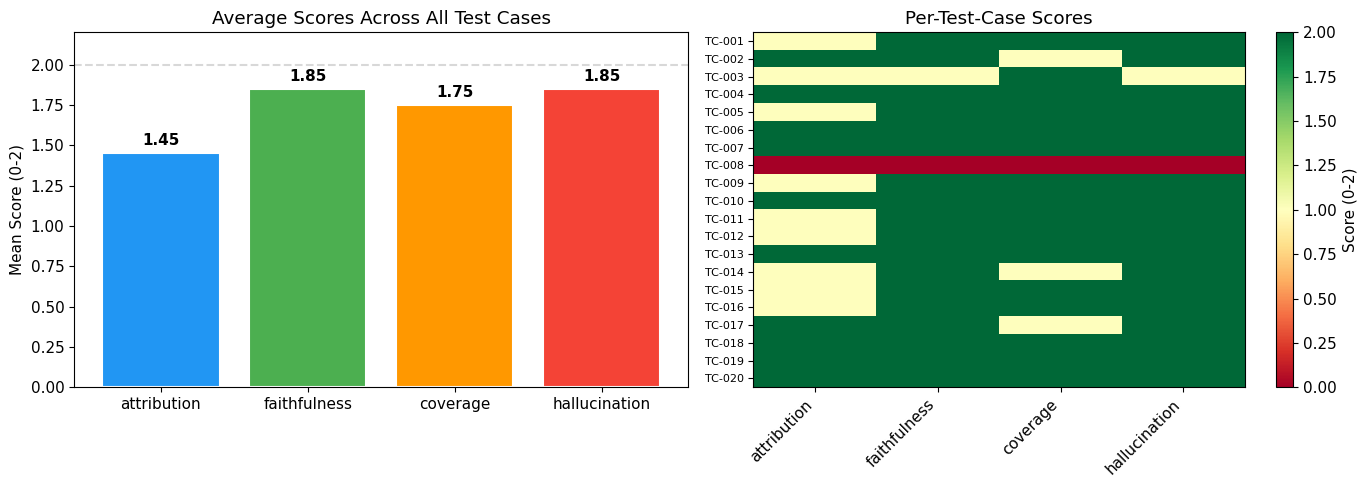

In [12]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({"font.size": 11})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Mean scores bar chart ---
ax = axes[0]
colors = ["#2196F3", "#4CAF50", "#FF9800", "#F44336"]
means = df[SCORE_DIMS].mean()
bars = ax.bar(SCORE_DIMS, means, color=colors, edgecolor="white", linewidth=1.5)
ax.set_ylim(0, 2.2)
ax.set_ylabel("Mean Score (0-2)")
ax.set_title("Average Scores Across All Test Cases")
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f"{val:.2f}", ha="center", fontweight="bold")
ax.axhline(y=2, color="gray", linestyle="--", alpha=0.3, label="Max (2)")

# --- Right: Per-test-case heatmap ---
ax = axes[1]
score_matrix = df.set_index("test_case_id")[SCORE_DIMS].dropna()
im = ax.imshow(score_matrix.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=2)
ax.set_xticks(range(len(SCORE_DIMS)))
ax.set_xticklabels(SCORE_DIMS, rotation=45, ha="right")
ax.set_yticks(range(len(score_matrix)))
ax.set_yticklabels(score_matrix.index, fontsize=8)
ax.set_title("Per-Test-Case Scores")
plt.colorbar(im, ax=ax, label="Score (0-2)")

plt.tight_layout()
plt.show()

## Identify Weak Test Cases

Flag test cases that scored low on any dimension — useful for debugging the agent.

In [13]:
# Test cases where any score is 0 or 1
weak = df[df[SCORE_DIMS].min(axis=1) <= 1].copy()
weak = weak.sort_values("composite_score")

if len(weak) == 0:
    print("All test cases scored 2/2 on every dimension!")
else:
    print(f"Found {len(weak)} test case(s) with at least one score <= 1:\n")
    for _, row in weak.iterrows():
        flags = [col for col in SCORE_DIMS if row[col] <= 1]
        print(f"  {row['test_case_id']} (composite={row['composite_score']:.2f})")
        print(f"    Subject: {row['subject'][:80]}")
        print(f"    Low scores: {', '.join(f'{f}={int(row[f])}' for f in flags)}")
        if row.get("justification"):
            print(f"    Justification: {row['justification'][:200]}")
        print()

Found 12 test case(s) with at least one score <= 1:

  TC-008 (composite=0.00)
    Subject: Conduct enhanced due diligence on SINGH, Chiranjeev Kumar.
    Low scores: attribution=0, faithfulness=0, coverage=0, hallucination=0
    Justification: The report is entirely hallucinated as the provided evidence explicitly states "(no evidence retrieved)". Despite this, the report fabricates findings regarding internal knowledge base searches, wire 

  TC-003 (composite=0.62)
    Subject: Stakeholder flagged Jeff Young for further investigation: No risk concerns; comm
    Low scores: attribution=1, faithfulness=1, hallucination=1
    Justification: The report covers all key evidence, including watchlist results, transaction details, and web search findings. Attribution is mostly present, with citations for web search and transactions, but the in

  TC-014 (composite=0.75)
    Subject: Please review Sam Bankman-Fried — flagged during onboarding screening.
    Low scores: attribution=1, coverage

## Export Results

Save evaluation results to JSON and CSV for downstream use.

In [14]:
output_dir = Path("output/llm_judge_eval")
output_dir.mkdir(parents=True, exist_ok=True)

# CSV
csv_out = output_dir / "groundedness_scores.csv"
df.to_csv(csv_out, index=False)
print(f"Saved CSV: {csv_out}")

# JSON (includes Evaluation-compatible format for integration with evaluate.py)
json_path = output_dir / "groundedness_scores.json"
export_data = {
    "metric_name": METRIC_NAME,
    "judge_config": {"model": JUDGE_CONFIG.model, "temperature": JUDGE_CONFIG.temperature},
    "num_test_cases": len(df),
    "aggregate_scores": {dim: round(df[dim].mean(), 3) for dim in SCORE_DIMS},
    "composite_groundedness": round(df["composite_score"].mean(), 3),
    "per_test_case": [
        {
            "test_case_id": row["test_case_id"],
            **{dim: row[dim] for dim in SCORE_DIMS},
            "justification": row.get("justification"),
            "error": row.get("error"),
            # Evaluation objects (same schema used by experiment.py / Langfuse upload)
            "evaluations": [
                {"name": e.name, "value": e.value, "comment": e.comment}
                for e in evaluations_by_tc.get(row["test_case_id"], [])
            ],
        }
        for row in results
    ],
}
with open(json_path, "w") as f:
    json.dump(export_data, f, indent=2, default=str)
print(f"Saved JSON: {json_path}")

print(f"\nFinal composite groundedness score: {df['composite_score'].mean():.3f}")
print(f"Judge calls logged to: run_log/llm_as_judge/")

Saved CSV: output/llm_judge_eval/groundedness_scores.csv
Saved JSON: output/llm_judge_eval/groundedness_scores.json

Final composite groundedness score: 0.863
Judge calls logged to: run_log/llm_as_judge/
